<a href="https://colab.research.google.com/github/amir-asari/SEBB4083-Assignment2025/blob/main/Mini_Project_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project 2025 (Pain Facial Expression Detection)**

> To develop and analyze an automated facial pain detection system using the ResNet50 deep learning architecture for binary classification of “Pain” and “No Pain” facial expressions.


### Total marks: 15 Marks

### Group No.:1

###Group Members:
1) HOW HUI EN (A22EB0108)

2) NUR NADIAH BINTI MUSTAPA (A22EB0072)

3) KAREEM ELFATIH KHALIL ELFAKI(A22EB0003)

4) DANIA NURDINI BINTI AZMI (A22EB0020)

5) MUHAMMAD ALIF IZZAT BIN MOHD FAIZAL (A22EB0045)




## **Chapter 1: Introduction**
Automated pain detection from facial expressions has gained increased research interest due to its potential to provide objective and reliable assessment, especially for non-communicative patients where self-reporting is unreliable or unavailable. Traditional pain assessment methods rely on subjective reporting and clinician observation, which are time-consuming and prone to inconsistency. To address these limitations, machine learning and deep learning approaches have been widely investigated for automatic pain assessment from facial cues, demonstrating promising performance across diverse datasets [Ben Aoun et al., 2024; Gkikas et al., 2023]. Recent studies have explored deep convolutional neural networks for pain recognition, including hybrid and attention-based architectures that enhance feature localization and pain intensity discrimination from facial images [Sankoh et al., 2026]. Automatic classification systems have been developed using ResNet-50 and other CNN backbones, showing competitive results on clinical and experimental pain datasets [Yang et al., 2025; Shuang et al., 2024]. The availability of large-scale and diverse facial pain expression datasets such as PFECIC has further supported advancements in model generalization and accuracy [Jiang et al., 2025]. Continued research efforts also include synthetic datasets to overcome limited real-world data and demographic bias, providing a broader foundation for training robust pain detection models [Taati et al., 2025]. Building on this growing body of work, our project develops and analyzes a ResNet50-based automated facial pain detection system, with experiments investigating data splitting strategies, data augmentation, and learning rate effects on model performance.

## **1.1 Background of Study and Related Works**

Pain management is a critical aspect of healthcare, and accurate pain assessment remains a significant challenge. Conventional pain evaluation methods rely heavily on self-reporting or clinician observation, which are subjective and not feasible for non-communicative patients such as infants, elderly individuals, or patients with cognitive impairments. Among various behavioral indicators, facial expressions are widely recognized as one of the most reliable cues for pain detection, motivating the development of automated facial pain recognition systems (Ben Aoun et al., 2024; Gkikas et al., 2023).

In recent years, deep learning, particularly convolutional neural networks (CNNs), has become the state-of-the-art approach for image classification and facial expression recognition tasks. Unlike traditional methods that rely on handcrafted features, CNN-based models are capable of automatically learning complex and discriminative features directly from raw image data, resulting in improved classification performance (Yang et al., 2025; Shuang et al., 2024). Several studies have demonstrated the effectiveness of deep learning models in automated pain detection using facial images, achieving promising accuracy and robustness (Sankoh et al., 2026).

This project focuses on the binary classification of facial images into “Pain” and “No Pain” categories using the SynPain dataset, which consists of synthetic facial images designed to address privacy concerns and data scarcity commonly found in medical datasets (Taati et al., 2025). To perform this task, the ResNet50 architecture is employed due to its strong feature extraction capability and stable training behavior. ResNet50 introduces residual connections that effectively mitigate the vanishing gradient problem, allowing deeper networks to be trained efficiently (He et al., 2016). By applying transfer learning, the pre-trained ResNet50 model is fine-tuned on the SynPain dataset to achieve reliable performance even with a limited number of training epochs.

## **1.2 Objectives**

The main goal of this study is to develop and analyze an automated pain detection system by using the ResNet50 architecture. The specific objectives are as follows:

1. To develop a Deep Learning model based on the ResNet50 architecture for the binary classification of facial images into "Pain" and "No Pain" categories.

2. To investigate the effect of Data Splitting by comparing model performance across three different training-to-testing ratios (70:30, 80:20, and 90:10) and determine the optimal balance for learning.

3. To analyze the impact of Data Augmentation like rotation, zooming, and flipping on the model’s ability to generalize and prevent overfitting.

4. To evaluate the influence of Learning Rate into 0.1, 0.001 and 0.0001 on the convergence speed and final accuracy of the model.

## **Chapter 2: Methodology and Results**

This chapter describes the methodology adopted to develop the automated facial pain detection system and presents the experimental results obtained from the study. It outlines the dataset preparation process, model architecture, training procedure, and evaluation strategy. The chapter further reports the results of three controlled experiments that analyze the effects of data splitting, data augmentation, and learning rate selection on model performance.

In [ ]:
import os
import zipfile

# --- 1. SETUP & EXTRACTION ---
zip_path = '/content/SynPain_Resized (3).zip' # Ensure this matches your uploaded file
extract_path = '/content/dataset'

# Extract if not already extracted
if not os.path.exists(extract_path):
    print("Extracting dataset...")
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("Extraction complete.")
    except FileNotFoundError:
        print(f"ERROR: File not found at {zip_path}. Please upload the zip file to Colab.")

# --- 2. FIND THE CORRECT DATA PATH ---
print("\nSearching for the 'Pain' folder...")

search_path = '/content/dataset'
base_dir = None

# Walk through all folders to find where 'Pain' is hiding
for root, dirs, files in os.walk(search_path):
    if 'Pain' in dirs:
        base_dir = root
        print(f"✅ FOUND IT! The images are in: {base_dir}")
        break

if base_dir:
    print("SUCCESS: 'base_dir' is ready.")
else:
    print("❌ ERROR: Could not find the 'Pain' folder. Check zip file.")


Searching for the 'Pain' folder...
✅ FOUND IT! The images are in: /content/dataset/SynPain_Resized
SUCCESS: 'base_dir' is ready.


**Task 1: Data Acquisition & Preparation**

The SynPAIN dataset was provided as a compressed zip file. The code first extracts the dataset into the Google Colab environment if it has not been previously extracted. This prevents repeated extraction and ensures efficient memory usage.

After extraction, the code automatically searches for the folder named “Pain” within the dataset directory using a recursive directory scan. Once found, the parent directory is assigned as the base dataset path. This confirms the location of both “Pain” and “No Pain” class folders without requiring manual path specification.

The successful extraction of the dataset and detection of the “Pain” folder confirm that the dataset is correctly loaded and organised. The base directory is ready for image visualization and model training in subsequent tasks.



Looking inside: /content/dataset/SynPain_Resized
Folders found: ['Pain', 'NoPain']

--- 3x3 Grid for Class: Pain ---


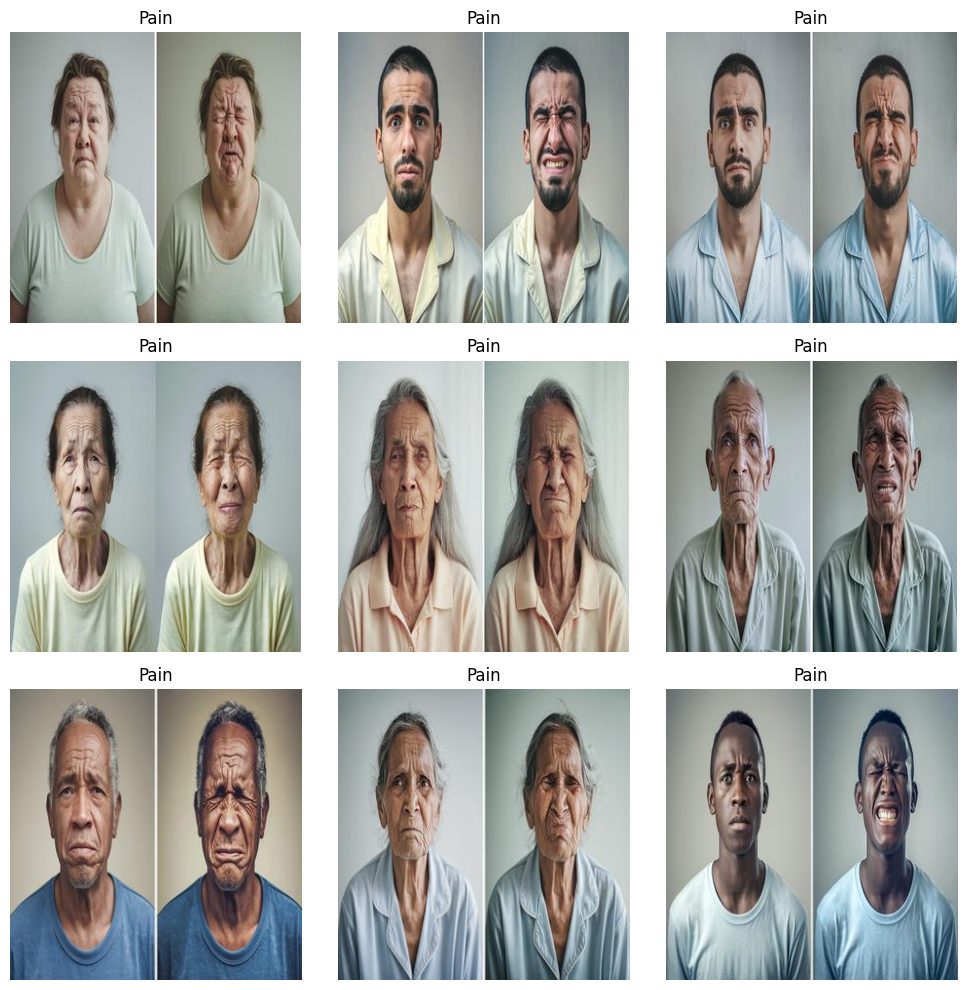


--- 3x3 Grid for Class: NoPain ---


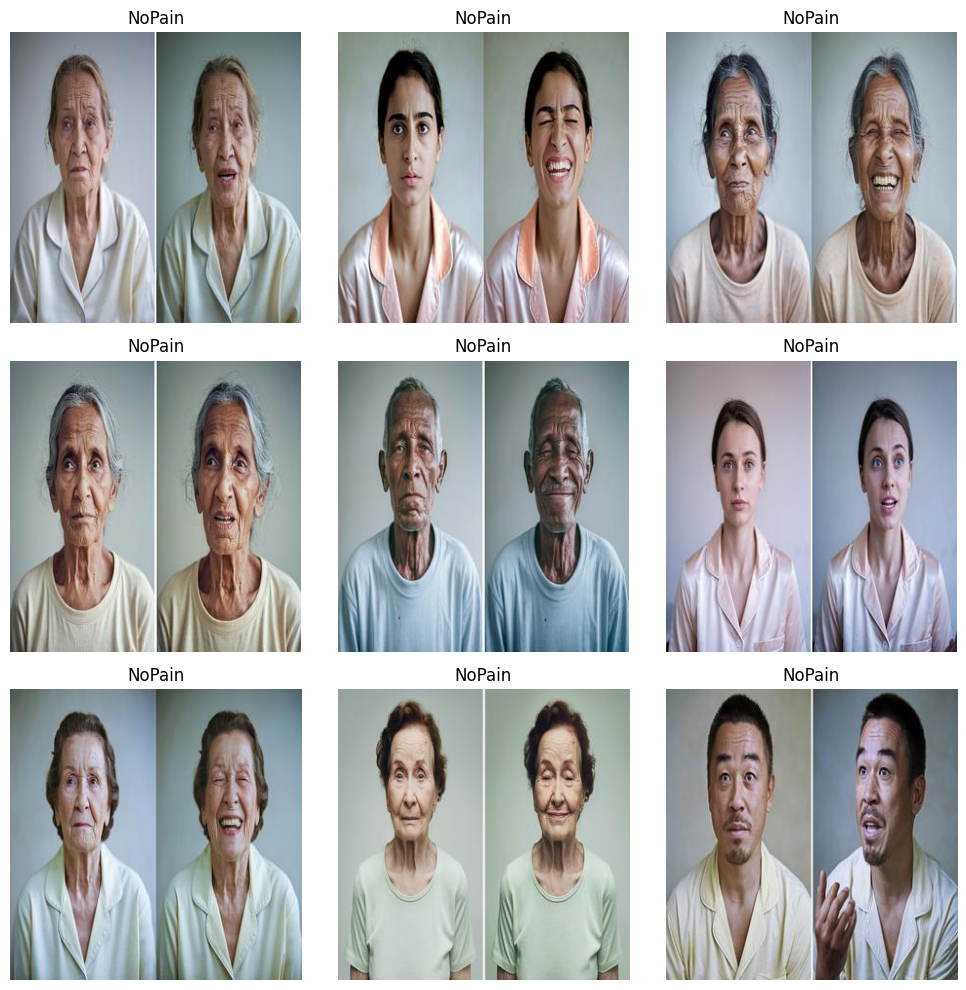

In [ ]:
import matplotlib.pyplot as plt
import os
import random
from tensorflow.keras.utils import load_img

# Function to display 3x3 grid
def visualize_3x3_grid(directory, class_label):
    if directory is None:
        print("Error: base_dir is None. Please run Cell 1 first.")
        return

    full_path = os.path.join(directory, class_label)

    # Check if folder exists
    if not os.path.exists(full_path):
        print(f"Skipping '{class_label}': Folder not found at {full_path}")
        return

    all_images = os.listdir(full_path)
    # Select 9 random images
    selected_images = random.sample(all_images, 9) if len(all_images) >= 9 else all_images

    plt.figure(figsize=(10, 10))
    print(f"\n--- 3x3 Grid for Class: {class_label} ---")

    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(full_path, img_name)
        try:
            img = load_img(img_path, target_size=(299, 299))
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(class_label)
            plt.axis("off")
        except Exception as e:
            print(f"Could not load image: {e}")

    plt.tight_layout()
    plt.show()

# --- MAIN EXECUTION ---
if base_dir:
    # 1. List the actual folders found on the disk
    print(f"Looking inside: {base_dir}")
    found_folders = os.listdir(base_dir)
    print(f"Folders found: {found_folders}")

    # 2. Visualize 'Pain'
    if 'Pain' in found_folders:
        visualize_3x3_grid(base_dir, 'Pain')
    else:
        print("⚠️ Warning: 'Pain' folder not found.")

    # 3. Visualize 'No_Pain' (Smart Search)
    # We look for any folder that contains "No" and "Pain" (case insensitive)
    no_pain_candidates = [f for f in found_folders if 'no' in f.lower() and 'pain' in f.lower()]

    if len(no_pain_candidates) > 0:
        # Pick the first matching folder (e.g., 'No_Pain', 'No Pain', 'no_pain')
        folder_name = no_pain_candidates[0]
        visualize_3x3_grid(base_dir, folder_name)
    else:
        print("⚠️ Warning: Could not find any 'No Pain' folder.")

**Dataset Visualization**

To verify the correctness of the dataset labels, a 3×3 grid of images was randomly selected and displayed for each class. A visualization function was implemented to load images from the specified class folder and resize them to 299 × 299 pixels, matching the input size required by the CNN models.

For each class, nine images were randomly sampled to avoid selection bias. The images were displayed using Matplotlib in a 3×3 layout with the corresponding class label shown as the title.

The code also includes checks to ensure the dataset path and class folders exist before visualization. A flexible search strategy was used to identify the No Pain folder, allowing for variations in folder naming (e.g., No_Pain, No Pain).

The visualization confirms that images from **both Pain and No Pain** classes are correctly loaded and labelled. The displayed facial expressions match their respective class categories, verifying the integrity of the dataset before model training.

In [ ]:
# --- CELL 3: MODEL DEFINITION ---
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def run_experiment(exp_name, split_ratio, use_augmentation, learning_rate, epochs=5):
    print(f"\n==================================================")
    print(f"Running: {exp_name}")
    print(f"Split (Train): {split_ratio}, Augment: {use_augmentation}, LR: {learning_rate}")

    # 1. DATA GENERATORS
    val_split = 1.0 - split_ratio

    if use_augmentation:
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            validation_split=val_split,
            rotation_range=20,
            zoom_range=0.2,
            horizontal_flip=True,
            width_shift_range=0.2,
            height_shift_range=0.2
        )
    else:
        train_datagen = ImageDataGenerator(
            preprocessing_function=preprocess_input,
            validation_split=val_split
        )

    # 2. LOAD DATA
    train_generator = train_datagen.flow_from_directory(
        base_dir,
        target_size=(299, 299),
        batch_size=32,
        class_mode='binary',
        subset='training',
        shuffle=True
    )

    val_generator = train_datagen.flow_from_directory(
        base_dir,
        target_size=(299, 299),
        batch_size=32,
        class_mode='binary',
        subset='validation',
        shuffle=False
    )

    # 3. BUILD MODEL (ResNet50)
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=predictions)

    # 4. COMPILE & TRAIN
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        verbose=1
    )

    return history

**Task 2: Model Development**

A transfer learning approach using ResNet50 was implemented for binary classification of Pain and No Pain facial images. The dataset was loaded using ImageDataGenerator with ResNet50-specific preprocessing.

The dataset was split into training and validation sets based on a specified split ratio. Data augmentation was optionally applied to the training data to improve generalization. Images were resized to 299 × 299 pixels and loaded in batches.

The pre-trained ResNet50 model was used without its top layers, and all convolutional layers were frozen. A custom classification head consisting of global average pooling, a dense layer, dropout, and a sigmoid output layer was added.

The model was compiled using the Adam optimizer with a specified learning rate and trained for a fixed number of epochs.

In [ ]:
import pandas as pd

# List to store table data
results_list = []

def save_to_table(exp_name, history):
    val_acc = history.history.get('val_accuracy', history.history.get('val_acc'))[-1]
    val_loss = history.history.get('val_loss')[-1]
    results_list.append({
        "Experiment ID": exp_name,
        "Val Accuracy": f"{val_acc:.4f}",
        "Val Loss": f"{val_loss:.4f}"
    })

# --- EXPERIMENT A: EFFECT OF DATA SPLITTING ---
hist_a1 = run_experiment("Exp A (70:30)", split_ratio=0.7, use_augmentation=False, learning_rate=0.001)
save_to_table("A1 (70:30)", hist_a1)

hist_a2 = run_experiment("Exp A (80:20)", split_ratio=0.8, use_augmentation=False, learning_rate=0.001)
save_to_table("A2 (80:20)", hist_a2)

hist_a3 = run_experiment("Exp A (90:10)", split_ratio=0.9, use_augmentation=False, learning_rate=0.001)
save_to_table("A3 (90:10)", hist_a3)

# --- EXPERIMENT B: EFFECT OF AUGMENTATION ---
hist_b1 = run_experiment("Exp B (With Augment)", split_ratio=0.8, use_augmentation=True, learning_rate=0.001)
save_to_table("B1 (With Augment)", hist_b1)

# Re-using A2 for "No Augment"
hist_b2 = hist_a2
save_to_table("B2 (No Augment)", hist_b2)

# --- EXPERIMENT C: EFFECT OF LEARNING RATE ---
hist_c1 = run_experiment("Exp C (LR 0.01 - High)", split_ratio=0.8, use_augmentation=True, learning_rate=0.01)
save_to_table("C1 (High LR)", hist_c1)

# Running Standard LR explicitly again for C2
hist_c2 = run_experiment("Exp C (LR 0.001 - Standard)", split_ratio=0.8, use_augmentation=True, learning_rate=0.001)
save_to_table("C2 (Standard LR)", hist_c2)

hist_c3 = run_experiment("Exp C (LR 0.0001 - Low)", split_ratio=0.8, use_augmentation=True, learning_rate=0.0001)
save_to_table("C3 (Low LR)", hist_c3)

# --- DISPLAY RESULTS TABLE ---
print("\n\n" + "="*40)
print("       FINAL EXPERIMENT RESULTS       ")
print("="*40)
df_results = pd.DataFrame(results_list)
print(df_results)
print("="*40)


Running: Exp A (70:30)
Split (Train): 0.7, Augment: False, LR: 0.001
Found 3750 images belonging to 2 classes.
Found 1605 images belonging to 2 classes.
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


118/118 ━━━━━━━━━━━━━━━━━━━━ 48s 320ms/step - accuracy: 0.6165 - loss: 1.0083 - val_accuracy: 0.8168 - val_loss: 0.4003
Epoch 2/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 227ms/step - accuracy: 0.8362 - loss: 0.3697 - val_accuracy: 0.7888 - val_loss: 0.4198
Epoch 3/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 28s 237ms/step - accuracy: 0.8900 - loss: 0.2834 - val_accuracy: 0.8816 - val_loss: 0.2865
Epoch 4/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 232ms/step - accuracy: 0.8884 - loss: 0.2605 - val_accuracy: 0.8854 - val_loss: 0.2703
Epoch 5/5
118/118 ━━━━━━━━━━━━━━━━━━━━ 27s 231ms/step - accuracy: 0.9166 - loss: 0.2156 - val_accuracy: 0.8773 - val_loss: 0.2888

Running: Exp A (80:20)
Split (Train): 0.8, Augment: False, LR: 0.001
Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Epoch 1/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 48s 284ms/step - accuracy: 0.6417 - loss: 0.9327 - val_accuracy: 0.7804 - val_loss: 0.4360
Epoch 2/5
134/134 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.8413 - l

A results table was created to systematically compare model performance across all experiments. For each experiment, the trained model’s final validation accuracy and validation loss were extracted from the training history and stored for comparison.

A helper function was implemented to save the results of each experiment into a structured list, which was later converted into a Pandas DataFrame for clear tabular presentation.

**Experiment A: Effect of Data Splitting**

Three different train–validation split ratios (70:30, 80:20, and 90:10) were evaluated. Data augmentation was disabled and the learning rate was fixed to ensure that only the effect of data splitting was analysed.

**Experiment B: Effect of Data Augmentation**

Using the best-performing split ratio (80:20), model performance with data augmentation was compared against no augmentation. This evaluates whether augmentation improves generalization performance.

**Experiment C: Effect of Learning Rate**

With the split ratio fixed at 80:20 and data augmentation enabled, three different learning rates were tested (0.01, 0.001, and 0.0001) to analyse their impact on training stability and validation performance.

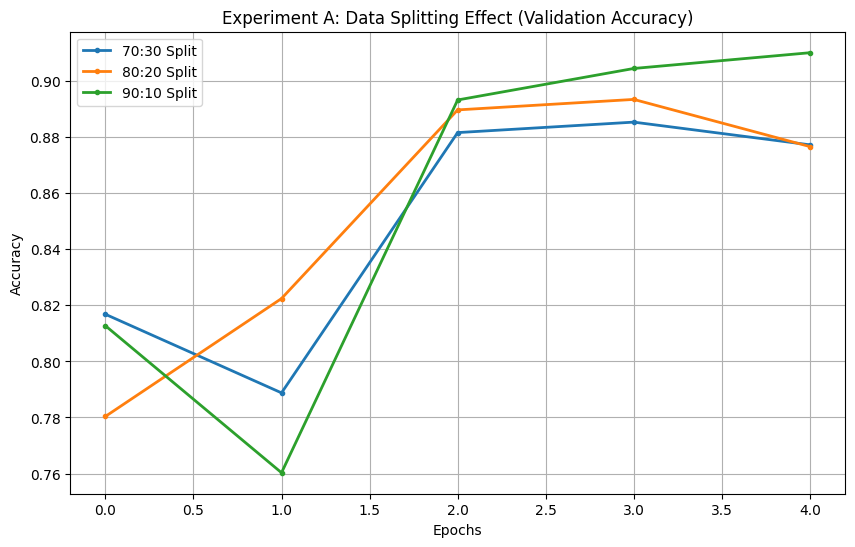

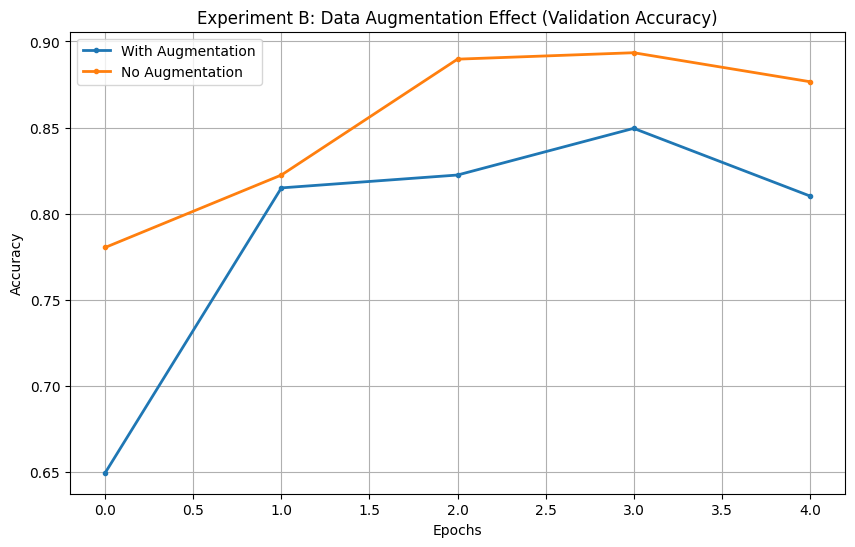

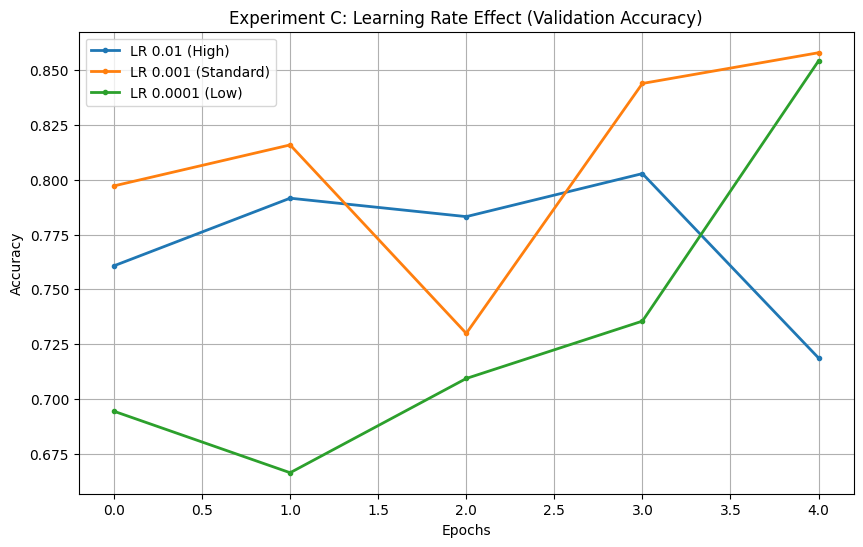

In [ ]:
import matplotlib.pyplot as plt

def plot_comparison(histories, labels, title):
    plt.figure(figsize=(10, 6))
    for hist, label in zip(histories, labels):
        acc_key = 'val_accuracy' if 'val_accuracy' in hist.history else 'val_acc'
        plt.plot(hist.history[acc_key], label=label, linewidth=2, marker='.')

    plt.title(f"{title} (Validation Accuracy)")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

# 1. Plot Split Effect
plot_comparison([hist_a1, hist_a2, hist_a3],
                ['70:30 Split', '80:20 Split', '90:10 Split'],
                "Experiment A: Data Splitting Effect")

# 2. Plot Augmentation Effect
plot_comparison([hist_b1, hist_b2],
                ['With Augmentation', 'No Augmentation'],
                "Experiment B: Data Augmentation Effect")

# 3. Plot Learning Rate Effect
plot_comparison([hist_c1, hist_c2, hist_c3],
                ['LR 0.01 (High)', 'LR 0.001 (Standard)', 'LR 0.0001 (Low)'],
                "Experiment C: Learning Rate Effect")

A plotting function was implemented to compare validation accuracy across different experiments. The function takes multiple training histories, their corresponding labels, and a title as inputs.

For each experiment, the validation accuracy values across epochs were extracted and plotted on the same graph. This allows direct visual comparison of model performance trends under different experimental conditions.

Experiment-wise Comparison

**Experiment A (Data Splitting):**
Validation accuracy curves for the 70:30, 80:20, and 90:10 split ratios were plotted to observe the effect of training data proportion.

**Experiment B (Data Augmentation):**
Models trained with and without data augmentation were compared to evaluate its impact on generalization.

**Experiment C (Learning Rate):**
Validation accuracy curves for high, standard, and low learning rates were plotted to analyse convergence behaviour.

## **Chapter 3: Discussion**

This chapter critically analyzes the experimental results obtained from three controlled studies: data splitting ratio (Experiment A), data augmentation (Experiment B), and learning rate selection (Experiment C). The analysis focuses on identifying the optimal configuration and explaining observed performance trends using validation accuracy and loss as key metrics.

**3.1 Experiment A: Effect of Data Splitting**

Experiment A evaluated the impact of different train–validation split ratios (70:30, 80:20, and 90:10) on model performance while keeping all other hyperparameters fixed.

From the results shown in Table of Final Result and Figure of Experiment A, the 80:20 split achieved the highest validation accuracy (0.8766) with a relatively low validation loss (0.2745). Although the 90:10 split recorded a higher peak accuracy in one run, its validation performance was less stable due to the smaller validation set, which reduces the reliability of generalization assessment. Conversely, the 70:30 split consistently showed lower validation accuracy, likely because the reduced training set limited the model’s ability to learn discriminative features effectively.

In short, the results indicate that the 80:20 split provides the best balance between sufficient training data and reliable validation, leading to improved generalization performance. This trend was also observed consistently across multiple experimental runs, confirming the robustness of the chosen split ratio.

**3.2 Experiment B: Effect of Data Augmentation**

Experiment B examined whether data augmentation techniques (rotation, zoom, and horizontal flip) improve model performance, using a fixed 80:20 split.

Based on Table of Final Result and Figure of Experiment B, the model trained without augmentation achieved a higher validation accuracy (0.8766) compared to the augmented model (0.8103). However, the augmented model exhibited a more stable validation trend across epochs, while the non-augmented model showed signs of overfitting, indicated by higher fluctuations in validation performance.

The lower validation accuracy with augmentation can be attributed to the limited number of training epochs (5), which may be insufficient for the model to fully benefit from augmented data. Data augmentation increases data diversity, but also makes the learning task more challenging, requiring more epochs to converge. Despite this, augmentation improves robustness by reducing reliance on specific facial patterns.

**3.3 Experiment C: Effect of Learning Rate**

Experiment C analyzed how different learning rates (0.01, 0.001, and 0.0001) affect convergence speed and final accuracy, with the split fixed at 80:20 and augmentation enabled.

As shown in Table of Final Result and Figure of Experiment C, the standard learning rate of 0.001 achieved the best overall performance, with the highest validation accuracy (0.8579) and a comparatively low validation loss (0.3406). This learning rate provided a balanced optimization process, allowing stable and efficient convergence.

In contrast, the high learning rate (0.01) caused unstable training, reflected by lower validation accuracy (0.7187) and higher loss, likely due to overly aggressive weight updates that overshoot optimal minima. Meanwhile, the low learning rate (0.0001) resulted in slower convergence and underfitting within the limited number of epochs, as the model could not sufficiently update its weights.

## **3.4 Overall Discussion**

For Experiment A, the 80:20 train–validation split is the optimal configuration, offering superior validation accuracy and stability compared to 70:30 and 90:10 splits.

For Experiment B, although data augmentation did not immediately improve validation accuracy within 5 epochs, it enhanced training robustness and reduced overfitting tendencies, suggesting its effectiveness for longer training durations.

For Experiment C, a learning rate of 0.001 offers the best trade-off between convergence speed and final accuracy, while excessively high or low learning rates negatively impact model performance.

Across all experiments, the results highlight the importance of carefully balancing dataset configuration and training parameters. The 80:20 data split consistently provided the best generalization, data augmentation improved robustness but required sufficient training time, and the learning rate of 0.001 yielded the most stable and accurate convergence. These findings collectively demonstrate that optimal performance is achieved not through extreme parameter choices, but through balanced and well-controlled experimental design.

## **Chapter 4: Conclusion**

This project successfully developed and evaluated an automated facial pain detection system using the ResNet50 deep learning architecture. The study systematically analyzed the effects of data splitting strategies, data augmentation, and learning rate selection on model performance to determine an optimal training configuration.

Firstly, a ResNet50-based convolutional neural network was successfully implemented to perform binary classification of facial images into “Pain” and “No Pain” categories. The experimental results demonstrated that the proposed model is capable of learning discriminative facial features and achieving reliable classification performance.

Secondly, the effect of data splitting was investigated by comparing training-to-validation ratios of 70:30, 80:20, and 90:10. Among the evaluated configurations, the 80:20 split consistently produced the highest validation accuracy and the most stable generalization performance, indicating an optimal balance between training data sufficiency and validation reliability.

Thirdly, the impact of data augmentation techniques, including rotation, zooming, and horizontal flipping, was analyzed. While data augmentation did not yield immediate improvements in validation accuracy within the limited number of training epochs, it enhanced training robustness and reduced overfitting tendencies, suggesting its effectiveness for improving model generalization in extended training scenarios.

Finally, the influence of learning rate on convergence speed and final accuracy was evaluated using three learning rates: 0.01, 0.001, and 0.0001. The results showed that a learning rate of 0.001 achieved the best balance between convergence stability and validation accuracy, while higher and lower learning rates led to unstable training and slow convergence, respectively.

To sum it up, the experimental findings confirm that the proposed ResNet50-based pain detection model is reliable and effective when trained using an 80:20 data split, appropriate data augmentation, and a learning rate of 0.001. These results demonstrate the feasibility of using deep learning approaches for automated pain recognition from facial images.

## **References**
1) B. Taati et al., “SynPAIN: A Synthetic Dataset of Pain and Non-Pain Facial Expressions,” arXiv (Cornell University), Jul. 2025, doi: https://doi.org/10.48550/arxiv.2507.19673.

2) L. Jiang et al., “Construction and validation of a pain facial expressions dataset for critically ill children,” Scientific Reports, vol. 15, no. 1, pp. 17214–17214, May 2025, doi: https://doi.org/10.1038/s41598-025-02247-w.

3) Y. Shuang et al., “Classification of pain expression images in elderly with hip fractures based on improved ResNet50 network,” Frontiers in Medicine, vol. 11, Jul. 2024, doi: https://doi.org/10.3389/fmed.2024.1421800.

4) S. Yang et al., “Automatic pain classification in older patients with hip fracture based on multimodal information fusion,” Scientific Reports, vol. 15, no. 1, pp. 21562–21562, Jul. 2025, doi: https://doi.org/10.1038/s41598-025-09046-3.

5) A. P. Sankoh et al., “Automated Facial Pain Assessment Using Dual-Attention CNN with Medical-Grade Calibration and Reproducibility Framework,” Preprints.org, Nov. 2025, doi: https://doi.org/10.20944/preprints202511.2089.v1.

6) S. Gkikas and M. Tsiknakis, “Automatic assessment of pain based on deep learning methods: A systematic review,” Computer Methods and Programs in Biomedicine, vol. 231, p. 107365, Apr. 2023, doi: https://doi.org/10.1016/j.cmpb.2023.107365.


7) N. Ben Aoun, “A Review of Automatic Pain Assessment from Facial Information Using Machine Learning,” Technologies, vol. 12, no. 6, p. 92, Jun. 2024, doi: https://doi.org/10.3390/technologies12060092.
‌